<a href="https://colab.research.google.com/github/AvinashOraon123/ML_Projects/blob/main/BCGA_Workshop_AvinashOraon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [62]:
import random
import math
import ipywidgets as widgets
from IPython.display import display, clear_output
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

In [63]:
cities_coords = {
    'Delhi': (28.6139, 77.2090),
    'Mumbai': (19.0760, 72.8777),
    'Kolkata': (22.5726, 88.3639),
    'Chennai': (13.0827, 80.2707),
    'Bengaluru': (12.9716, 77.5946),
    'Hyderabad': (17.3850, 78.4867),
    'Ahmedabad': (23.0225, 72.5714),
    'Guwahati': (26.1445, 91.7362),
    'Bhopal': (23.2599, 77.4126),
    'Lucknow':(26.8500	,80.9500),
    'Jaipur':	(26.9000,	75.8000),
    'Kanpur':	(26.4499,	80.3319),
    'Mirzapur':	(25.1460	,82.5690),
    'Nagpur':	(21.1497	,79.0806),
    'Ghaziabad':	(28.6700	,77.4200),
    'Supaul':(26.1260,	86.6050)



}

Considering the starting city as Delhi, all the other cities are binary encoded with 3 bits.

In [64]:
city_mapping = {
    '0000'   :'Mumbai',
    '0001'   :'Kolkata',
    '0010'   :'Chennai',
    '0011'   :'Bengaluru',
    '0100'   :'Hyderabad',
    '0101'   :'Ahmedabad',
    '0110'   :'Guwahati',
    '0111'   :'Bhopal',
    '1000'   :'Lucknow',
    '1001'   :'Jaipur',
    '1010'   :'Kanpur',
    '1011'   :'Mirzapur',
    '1100'   :'Nagpur',
    '1101'   :'Ghaziabad',
    '1110'   :'Supaul',
}

Haversine formula deterimes the great-circle distance between two points on a sphere if the longitudes and latitudes are given. For more details visit https://en.wikipedia.org/wiki/Haversine_formula

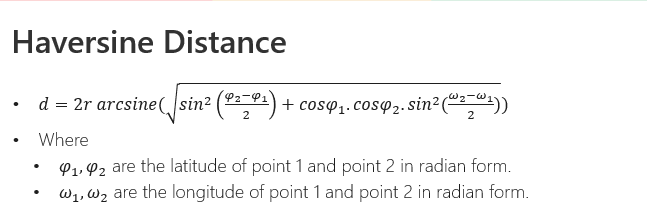

In [65]:
def haversine(c1, c2):
    coord1, coord2 = cities_coords[c1], cities_coords[c2]
    R = 6371
    lat1, lon1 = math.radians(coord1[0]), math.radians(coord1[1])
    lat2, lon2 = math.radians(coord2[0]), math.radians(coord2[1])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = math.sin(dlat/2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon/2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return R * c

During the GA iterations distance between different cities will be required repeatedly. Repeated calculation of the distance is costly, therefore they are precalculated.
```dist_matrix``` look like below

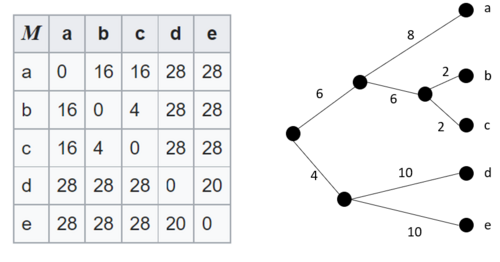

In [66]:
dist_matrix = {}
all_locs = ['Delhi'] + list(city_mapping.values())

for c1 in all_locs:
    for c2 in all_locs:
        dist_matrix[(c1, c2)] = haversine(c1, c2)

```create_inidvidual``` function creates string of 24 bits randomly taking encoded city from the list of 8 cities (```city_mapping```)

In [67]:
def create_individual():
    return ''.join(random.sample(list(city_mapping.keys()), 15))

In [68]:
''.join(random.sample(list(city_mapping.keys()), 8))

'11011011001111100100000001110010'

```create_population``` function create unique individuals of number ```size```. if no value is provided, default population size is 10

In [69]:
def create_population(size: int = 10):
    population = list()
    while len(population) < size:
        individual = create_individual()
        if individual not in population:
            population.append(individual)

    return population

```calculate_individual_dist``` is a helper function. The distance for a given route is calculated with the function. It uses the previously calculated ```dist_matrix``` for faster calculation.

In [70]:
def calculate_individual_dist(individual, city_mapping, start_city, distance_matrix:dict[tuple,float]):
    city_keys = [individual[i:i+4] for i in range(0, 60, 4)]
    path_names = [start_city] + [city_mapping[k] for k in city_keys] + [start_city]
    total_dist = 0
    for i in range(len(path_names) -1):
        c1 = path_names[i]
        c2 = path_names[i+1]

        total_dist += distance_matrix.get((c1, c2), 0)

    return total_dist

In [71]:
def calculate_cost_for_population(population, city_mapping, start_city, dist_matrix):
    population_with_cost  = []

    for individual in population:
        cost = calculate_individual_dist(individual, city_mapping, 'Delhi', dist_matrix)
        population_with_cost.append((individual, cost))

        # population_with_cost.sort(key=lambda x: x[1])

    return population_with_cost

Tournament selection scheme with default tournament size 2. Route with minimum total distance is selected as the winner from a sample of ```tournament_size``` for a given population.

In [72]:
def tournament_selection(population_with_cost, tournament_size=2):
    contestent = random.sample(population_with_cost, tournament_size)
    winner = min(contestent, key= lambda x: x[1])
    return winner

For cross over we have to consider few things:

1) we never split a city code like 011 into 0 and 11. Therefore splitting is done with 3 bits only.
2) Child 1 inherits the first N cities from Parent 1. These are kept "sacred" (locked).
3) Now we looks at the new cities appended from Parent 2. If a city in the tail is already in the head, it is a duplicate.
The function detects this duplicate and replaces it with a city from the missing list (cities that were in neither the head nor the tail).

In [73]:
def single_point_crossover(parent1, parent2, city_mapping, crossover_rate):

    if random.random() > crossover_rate:
        return parent1, parent2

    p1_chunks = [parent1[i:i+4] for i in range(0, 60, 4)]
    p2_chunks = [parent2[i:i+4] for i in range(0, 60, 4)]

    k = random.randint(1, 7)

    def cross_and_repair(parent_head, parent_tail_source):
        child = parent_head[:k] + parent_tail_source[k:]

        missing = list(set(city_mapping.keys()) - set(child))
        random.shuffle(missing)

        seen = set(parent_head[:k])
        for i in range(k, 15):
            city = child[i]
            if city in seen:
                child[i] = missing.pop()
                seen.add(child[i])
            else:
                seen.add(city)

        return "".join(child)

    c1 = cross_and_repair(p1_chunks, p2_chunks)
    c2 = cross_and_repair(p2_chunks, p1_chunks)

    return c1,c2

In mutation we randomly select two cities and swap there position with the string

In [74]:
def mutation(individual, mutation_rate=0.05):
    if random.random() > mutation_rate:
        return individual

    chunks = [individual[i:i+4] for i in range(0, 60, 4)]

    idx1, idx2 = random.sample(range(len(chunks)),2)

    chunks[idx1], chunks[idx2] = chunks[idx2], chunks[idx1]

    return "".join(chunks)

Main GA loop.

In [75]:
plot_output = widgets.Output()
india_map = gpd.read_file("India.geojson")


def run_ga(pop_size, generations, crossover_rate, mutation_rate, tournament_size):

    ## ========================= code related to plotting =====================
    fig, ax = plt.subplots(figsize=(10,12))
    plt.close(fig)
    if india_map is not None:
        india_map.plot(ax=ax, color='white', edgecolor='black', linewidth=0.5)

    lons = [v[1] for v in cities_coords.values()]
    lats = [v[0] for v in cities_coords.values()]
    ax.scatter(lons, lats, color='red', s=50, zorder=5, label='Cities')

    best_line_ref, = ax.plot([], [], 'b-', linewidth=2, label='Best Path')
    curr_line_ref, = ax.plot([], [], 'r--', alpha=0.3, label='Searching')

    ax.legend(loc='lower right')
    ax.set_title("Initializing...")
    ax.axis('off')
    with plot_output:
        print(
            f"Running GA with: Pop={pop_size}, Gens={generations}, Cross={crossover_rate}, Mut={mutation_rate}..."
        )
    #==============================================================================
    # Population genereation
    population = create_population(pop_size)
    best_cost_overall = float('inf')
    best_individual_overall = ''

    # main loop for number of generation
    for gen in range(generations):
        ranked_pop = calculate_cost_for_population(population, city_mapping, 'Delhi', dist_matrix)
        unique_costs = len(set(x[1] for x in ranked_pop))

        with plot_output:
            # clear_output(wait=True)
            print(f"Gen {gen}: Best={best_cost_overall}, Unique Scores={unique_costs}")
        current_best = min(ranked_pop, key= lambda x: x[1])
        if (current_best[1] < best_cost_overall):
            best_cost_overall = current_best[1]
            best_individual_overall = current_best[0]

        next_gen = []

        while len(next_gen) < pop_size:
            p1 = tournament_selection(ranked_pop, tournament_size)
            p2 = tournament_selection(ranked_pop, tournament_size)

            c1, c2 = single_point_crossover(p1[0], p2[0], city_mapping, crossover_rate)

            c1 = mutation(c1, mutation_rate)
            c2 = mutation(c2, mutation_rate)

            next_gen.append(c1)
            if len(next_gen) < pop_size:
                next_gen.append(c2)

        population = next_gen

        if gen % 5 == 0:
            def get_xy(individual):
                chunks = [individual[i:i+4] for i in range(0, 60, 4)]
                names = ['Delhi'] + [city_mapping[c] for c in chunks] + ['Delhi']
                return [cities_coords[n][1] for n in names], [cities_coords[n][0] for n in names]

            # Red Line (Search)
            x_curr, y_curr = get_xy(population[-1])
            # ax.plot(x_curr, y_curr, 'r--', alpha=0.3)

            # Blue Line (Best)
            x_best, y_best = get_xy(best_individual_overall)
            # ax.plot(x_best, y_best, 'b-', linewidth=2)

            best_line_ref.set_data(x_best, y_best)
            curr_line_ref.set_data(x_curr, y_curr)
            ax.set_title(f"Gen {gen} | Best: {best_cost_overall:.0f} km")

            with plot_output:
                clear_output(wait=True)
                display(fig)



    print("\n" + "="*40)
    print(f"FINAL RESULT")
    print("="*40)
    print(f"Best Distance: {best_cost_overall:.2f} km")
    # Decode Path
    chunks = [best_individual_overall[i:i+4] for i in range(0, 60, 4)]
    names = [city_mapping[c] for c in chunks]
    print(f"Route: {'Delhi'} -> {' -> '.join(names)} -> {'Delhi'}")

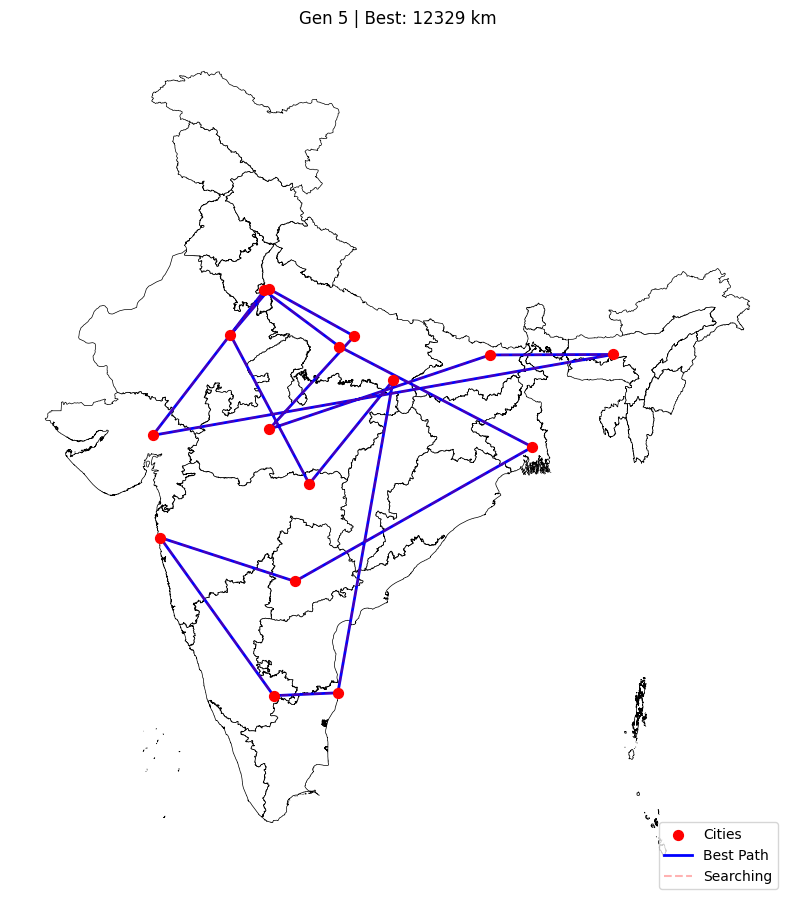


FINAL RESULT
Best Distance: 12329.09 km
Route: Delhi -> Kanpur -> Kolkata -> Hyderabad -> Mumbai -> Bengaluru -> Chennai -> Mirzapur -> Nagpur -> Jaipur -> Ghaziabad -> Lucknow -> Bhopal -> Supaul -> Guwahati -> Ahmedabad -> Delhi


In [76]:
plot_output = widgets.Output()

style = {'description_width':'initial'}
pop_slider = widgets.IntSlider(value=10, min=10, max=50, step=5, description='Population Size:', style=style)
gen_slider = widgets.IntSlider(value=10, min=5, max=50, step=5, description='Generations:', style=style)
cross_slider = widgets.FloatSlider(value=0.8, min=0.0, max=1.0, step=0.05, description='Crossover Rate:', style=style)
mut_slider = widgets.FloatSlider(value=0.01, min=0.0, max=0.05, step=0.01, description='Mutation Rate:', style=style)
tourn_slider = widgets.IntSlider(value=3, min=2, max=6, step=1, description='Tournament Size:', style=style)


# Run Button
run_btn = widgets.Button(description="Run Algorithm", button_style='success')
def on_button_clicked(b):
    plot_output.clear_output()
    run_ga(
        pop_size=pop_slider.value,
        generations=gen_slider.value,
        crossover_rate=cross_slider.value,
        mutation_rate=mut_slider.value,
        tournament_size=tourn_slider.value,
    )

run_btn.on_click(on_button_clicked)

# Display Interface
display(
    widgets.VBox([
        pop_slider, gen_slider, cross_slider, mut_slider, tourn_slider,
        run_btn,
        plot_output
    ])
)
